# Import data

## Import player position/rotation data
Read from .json and build dataframe

In [1]:
import json
import pandas as pd
import datetime as dt

FILENAME: str = "../data/savefile_01_pos_rot.json"
 
# 1. Load the raw JSON
with open(FILENAME, mode="r") as file:
    json_data: json = json.load(file)

# 2. Extract top-level metadata
player_id: str = json_data["playerId"]
save_time: dt.datetime = dt.datetime.strptime(json_data["saveDateTime"], "%Y-%m-%d %H:%M:%S")

# 3. Build rows from the list, reshaping position/rotation into tuples
rows: list[dict] = []
for entry in json_data["playerSaveObjectList"]:
    rows.append({
        "time":      entry["gametimer"],
        "position":  (entry["position"]["x"], entry["position"]["y"], entry["position"]["z"]),
        "rotation":  (entry["rotation"]["x"], entry["rotation"]["y"], entry["rotation"]["z"]),
        "playerId":  player_id,
        "saveTime":  save_time,
    })

# 4. Create the DataFrame
df: pd.DataFrame = pd.DataFrame(rows)

x_list: list[float] =  [x for (x,y,z) in df["position"]]
z_list: list[float] =  [z for (x,y,z) in df["position"]]
rot_y_list: list[float] = [y for (x,y,z) in df["rotation"]]
t_list: list[float] = [_ for _ in df["time"]]

print(df.head())
print("-----------")
print(df.dtypes)

       time           position                        rotation playerId  \
0  5.528239  (90.0, 0.0, 60.0)   (0.0, 46.83423614501953, 0.0)   id_001   
1  6.530888  (90.0, 0.0, 60.0)  (0.0, 107.00001525878906, 0.0)   id_001   
2  7.531301  (90.0, 0.0, 60.0)   (0.0, 95.61361694335938, 0.0)   id_001   
3  8.531610  (90.0, 0.0, 60.0)   (0.0, 95.61361694335938, 0.0)   id_001   
4  9.531744  (90.0, 0.0, 60.0)   (0.0, 87.09896087646484, 0.0)   id_001   

             saveTime  
0 2026-07-26 20:11:07  
1 2026-07-26 20:11:07  
2 2026-07-26 20:11:07  
3 2026-07-26 20:11:07  
4 2026-07-26 20:11:07  
-----------
time               float64
position            object
rotation            object
playerId               str
saveTime    datetime64[us]
dtype: object


## Import building data
Read from .json and import as Dataframe

In [2]:
BUILDING_FILENAME: str = "../data/buildings.json"
buildings_data: pd.DataFrame = pd.read_json(BUILDING_FILENAME).set_index("building_id")
print(buildings_data)

                   name door_orientation validation_color validation_symbol  \
building_id                                                                   
L1-01           Butcher            South              red            square   
L1-02              Barn             East           orange            circle   
L1-03            Potter             East            white          triangle   
L1-04          Windmill            North            green              star   
L1-05        Blacksmith             East            brown              moon   
L1-06            Tavern            South             pink             cross   
L1-07            Bakery             West           purple             arrow   
L1-08            Tailor            North           yellow        semicircle   
L1-09            Cooper             West             blue             cloud   

             grid_pos_x  grid_pos_z  world_pos_x  world_pos_z  
building_id                                                    
L1

# Model with charts

## Map configuration for Level 1

In [3]:
# MAP SIZE
GRID_COLS: int = 6
GRID_ROWS: int = 5
BLOCK_SIZE: int = 30

# The extent is computed — maps pixel corners to world coordinates
map_extent = [
    -BLOCK_SIZE / 2,
    (GRID_COLS - 0) * BLOCK_SIZE + BLOCK_SIZE / 2,
    -BLOCK_SIZE / 2,
    (GRID_ROWS - 0) * BLOCK_SIZE + BLOCK_SIZE / 2,
]

map_x_offset: int = BLOCK_SIZE / 2
map_z_offset: int = BLOCK_SIZE / 2

map_coord: list[int] = [
    -BLOCK_SIZE / 2,
    (GRID_COLS - 1) * BLOCK_SIZE + BLOCK_SIZE / 2,
    -BLOCK_SIZE / 2,
    (GRID_ROWS - 1) * BLOCK_SIZE + BLOCK_SIZE / 2,
]

map_coord[0] += map_x_offset  # left
map_coord[1] += map_x_offset  # right
map_coord[2] += map_z_offset  # bottom
map_coord[3] += map_z_offset  # top

## Map Graph

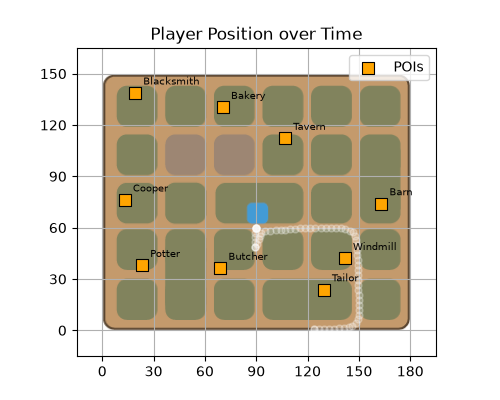

In [4]:
%matplotlib widget
import ipywidgets as widgets
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import matplotlib.image as mpimg
from matplotlib.animation import FuncAnimation

import numpy as np


# ---------- Graphs ---------- #

fig, ax = plt.subplots(figsize=(5,4))

# Add map image
MAP_IMAGE: str = "../images/map_level1.png"
map = mpimg.imread(MAP_IMAGE)
ax.imshow(map, extent=map_coord, origin="upper", aspect="equal")

# Plot all dots faded as a trail
trail, = ax.plot(x_list, z_list, 'o', color='white', alpha=0.25, markersize=5)

# Active path up to current time
path, = ax.plot([], [], '-o', color='cyan', markersize=4, linewidth=1)

# Current position marker
current, = ax.plot([], [], 'o', color='red', markersize=12, zorder=10)

buildings_scatter = ax.scatter(
    buildings_data["world_pos_x"],
    buildings_data["world_pos_z"],
    marker='s',        # squares
    c='orange',
    s=80,
    edgecolors='black',
    linewidths=0.8,
    zorder=6,
    label='POIs'
)

building_labels = []
for _, row in buildings_data.iterrows():
    label = ax.annotate(
        row["name"],  # building_id since it's the index
        (row["world_pos_x"], row["world_pos_z"]),
        textcoords="offset points",
        xytext=(6, 6),          # pixel offset from the dot
        fontsize=7,
        color="black",
        zorder=7
    )
    building_labels.append(label)

ax.set_title("Player Position over Time")
ax.legend()

ticks = np.arange(0,map_extent[1],30)
ax.set_xticks(ticks)
ax.set_yticks(ticks)

ax.set_xlim(map_extent[0], map_extent[1])
ax.set_ylim(map_extent[2], map_extent[3])

ax.grid()

# ---------- Orientation indicator ---------- #

SIZE = 4
base_triangle = np.array([
    [0, SIZE],
    [-SIZE/2, -SIZE/2],
    [SIZE/2, -SIZE/2],
])

tri_patch: Polygon = Polygon(base_triangle, closed=True, fc='red', ec='white', lw=1.5, zorder=11)
tri_patch.set_visible(False)  # hidden until first slider move

ax.add_patch(tri_patch) 



def update(frame):
    path.set_data(x_list[:frame+1], z_list[:frame+1])
    current.set_data([x_list[frame]], [z_list[frame]])

    # Triangle one frame ahead
    next_frame = min(frame + 1, len(x_list) - 1)
    angle = -rot_y_list[frame]
    rad = np.radians(angle)
    cos_a, sin_a = np.cos(rad), np.sin(rad)
    rotated = np.array([
        [v[0]*cos_a - v[1]*sin_a, v[0]*sin_a + v[1]*cos_a]
        for v in base_triangle
    ])
    rotated[:, 0] += x_list[next_frame]
    rotated[:, 1] += z_list[next_frame]
    tri_patch.set_xy(rotated)
    tri_patch.set_visible(True)

    ax.set_title(f"Time: {t_list[frame]:.1f}s  |  Rotation Y: {rot_y_list[frame]:.1f}°")
    fig.canvas.draw_idle()

def toggle_pois(change):
    visible = change['new']
    buildings_scatter.set_visible(visible)
    for label in building_labels:
        label.set_visible(visible)
    fig.canvas.draw_idle()

def on_save(b):
    save_status.value = "Saving..."
    anim = FuncAnimation(fig, update, frames=len(x_list), interval=100, repeat=False)
    anim.save("../saves/player_path.mp4", writer="ffmpeg", dpi=150)
    save_status.value = "Saved: player_path.mp4"

# UI - ipywidget

In [5]:
# ------- UI Elements ---------- #
play = widgets.Play(value=0, min=0, max=len(x_list)-1, step=1, interval=100)
slider = widgets.IntSlider(min=0, max=len(x_list)-1, step=1, value=0, description="Frame")

checkbox = widgets.Checkbox(value=True, description='Show POIs')
checkbox.observe(toggle_pois, names='value')

save_button = widgets.Button(description="Export Video")
save_button.on_click(on_save)
save_status = widgets.Label(value="")

widgets.jslink((play, 'value'), (slider, 'value'))
widgets.interactive_output(update, {'frame': slider})

ui = widgets.HBox([play, slider,checkbox, save_button, save_status])
display(ui)

current marker has zorder=10, the triangle has zorder=11. Higher zorder draws on top.

`tri_patch.set_zorder(15)`

### patches
A patch is a 2D artist with a face color and an edge color.
https://matplotlib.org/stable/api/patches_api.html

Why use `trail,`, `path,`, and `current,`?

ax.plot() returns a list, even for a single line. The comma unpacks it:

```python
# Without comma — trail is a list containing one Line2D object
trail = ax.plot(x_list, z_list)     # trail = [<Line2D>]

# With comma — trail is the Line2D object itself
trail, = ax.plot(x_list, z_list)    # trail = <Line2D>
````

Without it, you'd need trail[0].set_data(...) every time. With it, you get trail.set_data(...) directly.

It's the same syntax as a, = [42] — tuple unpacking a single-element iterable.